# A Python Package for the Simultaneous Global Sensitivity Analysis of Foreground and Background Parameters in Life Cycle Assessment
**Jonathan Larochelle** (1,2), Laura Maria Comella (1,2)
1 Institute for Energy-Efficient Mobility (IEEM), Karlsruhe University of Applied Sciences
2 Faculty of mechatronics and mechanical engineering, Karlsruhe University of Applied Sciences

Wednesday September 23rd, 15:30

**Agenda**
- Motivation: why create a new Python package for LCA and uncertainty apportioning?
- Description: introduction to ua LCA
- Demonstration: Case Study of an Environmental Sensor

## 1) Motivation
(...)

## 2) Description
(...)

## 3) Demonstration
We now demonstrate how ualca can be used for optimal iterative data collection for the case of an environmental sensor.

### 3.0) Brightway set-up

In [45]:
# Our package
import lcatoolbox

# Brightway
import bw2data as bd
from bw2data.parameters import ProjectParameter
import bw2io as bi

# Other packages
import pandas as pd
import matplotlib.pyplot as plt
from typing import Tuple
import textwrap

In [2]:
bd.projects.set_current("bc2026-w4-2-ualca")
lcatoolbox.reset_foreground()

In [3]:
if 'ecoinvent-3.12-cutoff' in bd.databases:
    print('ecoinvent 3.12 is already present in the project')
    # del bd.databases['ecoinvent-3.12-cutoff']
    # del bd.databases['ecoinvent-3.12-biosphere']
else:
    bi.import_ecoinvent_release(
        version='3.12',
        system_model='cutoff',  # can be cutoff / apos / consequential / EN15804
    )
    lcatoolbox.apply_openlca_preprocessing_to_ecoinvent("ecoinvent-3.12-cutoff")

ecoinvent 3.12 is already present in the project


### 3.1) Goal and Scope

In [4]:
# impact_categories = lcatoolbox.get_impact_categories("EF v3.1")
impact_categories = [('ecoinvent-3.12', 'EF v3.1', 'climate change', 'global warming potential (GWP100)'),
                     ('ecoinvent-3.12', 'EF v3.1', 'material resources: metals/minerals', 'abiotic depletion potential (ADP): elements (ultimate reserves)'),
                     ('ecoinvent-3.12', 'EF v3.1', 'water use', 'user deprivation potential (deprivation-weighted water consumption)')]

### 3.2) Initial Data Collection

In [5]:
new_activities = lcatoolbox.import_foreground("foreground_iter_0.ods",
                             data_quality_system="ciroth2016")

print("New activities:")
print(*new_activities, sep="\n")

New activities:
'Cradle-to-grave [battery-powered]' (item(s), DE, None)
'Cradle-to-grave [solar-powered]' (item(s), DE, None)
'Sensor assembly [common]' (item(s), DE, None)
'Sensor assembly [battery-powered]' (item(s), DE, None)
'Sensor assembly [solar-powered]' (item(s), DE, None)
'PCB assembly, power+sensor [common]' (item(s), DE, None)
'PCB assembly, power+sensor [battery-powered]' (item(s), DE, None)
'PCB assembly, power+sensor [solar-powered]' (item(s), DE, None)
'PCB assembly, mcu+lora' (item(s), DE, None)
'PCB assembly, solar cells' (item(s), DE, None)


In [6]:
parameter_names = [p.name for p in ProjectParameter.select()]
print("Parameter names:")
print(parameter_names)

Parameter names:
['ic_ina234_die_area_mm2', 'ic_sip32432_die_area_mm2', 'ic_as7341_die_area_mm2', 'ic_shtc3_die_area_mm2', 'ic_tpsm83100s_die_area_mm2', 'ic_bq25570_die_area_mm2', 'ic_msp430fr5969_die_area_mm2', 'ic_die_to_mass_ratio_cm2_per_kg', 'cap_smd_0603_mass_mg', 'cap_smd_0805_mass_mg', 'cap_tht_35_8_mass_g', 'ind_smd_3816_mass_mg', 'ind_smd_2813_mass_mg', 'ind_smd_0805_mass_mg', 'res_smd_0805_mass_mg', 'res_smd_0603_mass_mg', 'res_smd_2512_mass_mg', 'led_smd_0603_mass_mg', 'switch_mass_mg', 'crystal_mass_mg', 'lambda62_mass_g', 'connector_2x6_mass_mg', 'connector_sma_mass_mg', 'connector_2x5_mass_mg', 'bat_AAA_mass_g', 'bat_holder_2x_AAA_mass_g', 'pcb_power_sensor_area_mm2', 'pcb_solar_cells_area_mm2', 'pcb_mcu_lora_area_mm2', 'conn_spring_piston_3pos_smd_mass_mg', 'solar_cell_area_mm2', 'antenna_mass_g', 'housing_volume_mm3', 'pcb_spacer_volume_mm3', 'lid_volume_mm3', 'resin_mass_density_g_per_cm3', 'extra_resin_3d_print', 'housing_mass_g', 'pcb_spacer_mass_g', 'lid_mass_g', '

In [58]:
# Perform uncertainty apportioning and uncertainty analysis at the same time
act_battery_powered = bd.get_activity(name="Cradle-to-grave [battery-powered]")
act_solar_powered = bd.get_activity(name="Cradle-to-grave [solar-powered]")

ua_method = lcatoolbox.RegressionMethod(N=100)
df_ua, df_scores, df_parameters = lcatoolbox.uncertainty_apportioning(activities=[act_battery_powered, act_solar_powered],
                                                                      impact_categories=impact_categories,
                                                                      method=ua_method)

Uncertainty Apportioning: |--------------------------------------------------| 1/1000 (1.9 s elapsed, 1898.9 s remaining)
Uncertainty Apportioning: |--------------------------------------------------| 2/1000 (3.7 s elapsed, 1865.1 s remaining)
Uncertainty Apportioning: |--------------------------------------------------| 3/1000 (5.8 s elapsed, 1919.4 s remaining)
Uncertainty Apportioning: |--------------------------------------------------| 4/1000 (7.6 s elapsed, 1901.0 s remaining)
Uncertainty Apportioning: |--------------------------------------------------| 5/1000 (9.6 s elapsed, 1904.8 s remaining)
Uncertainty Apportioning: |--------------------------------------------------| 6/1000 (11.5 s elapsed, 1913.3 s remaining)
Uncertainty Apportioning: |--------------------------------------------------| 7/1000 (13.4 s elapsed, 1902.2 s remaining)
Uncertainty Apportioning: |--------------------------------------------------| 8/1000 (15.3 s elapsed, 1901.5 s remaining)
Uncertainty Apportion

KeyboardInterrupt: 

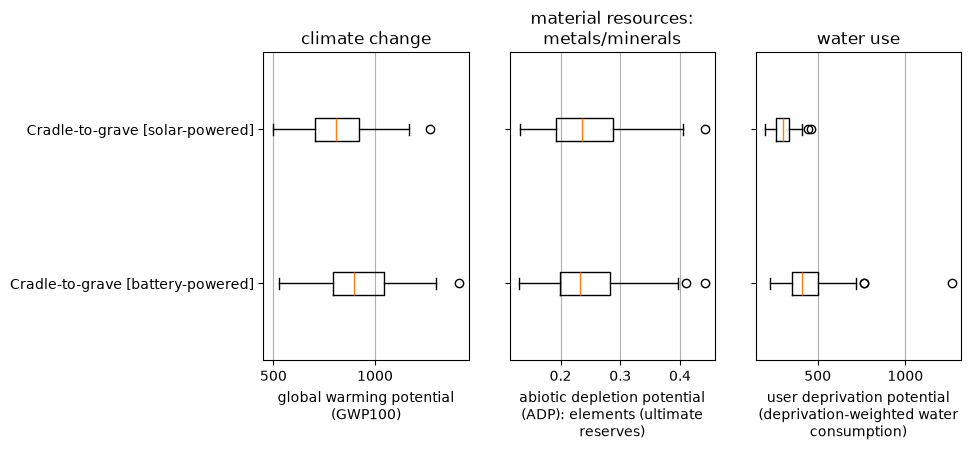

In [48]:
fig, axs = plt.subplots(1, 3, figsize=(9, 4))
axs = axs.flatten()

for ax, ic in zip(axs, impact_categories):
    ax.boxplot(x=df_scores[(df_scores["activity"] == lcatoolbox.activity_string(act_battery_powered)) &
                       (df_scores["impact_category"] == str(ic))]["values"].values[0],
           orientation="horizontal",
           positions=[0])
    ax.boxplot(x=df_scores[(df_scores["activity"] == lcatoolbox.activity_string(act_solar_powered)) &
                       (df_scores["impact_category"] == str(ic))]["values"].values[0],
           orientation="horizontal",
           positions=[1])
    ax.set_title(textwrap.fill(ic[2], width=30), wrap=True)
    ax.set_xlabel(textwrap.fill(ic[3], width=30))
    ax.grid(True, axis="x")
    ax.set_yticklabels([])

axs[0].set_yticks([0, 1], [act_battery_powered["name"], act_solar_powered["name"]])
#plt.tight_layout()

This is reflected in the discernability, with $P_{A>B}\approx0.84$.

In [35]:
discernability = lcatoolbox.discernibility_analysis(df_scores)
discernability[(discernability["activity_A"] == lcatoolbox.activity_string(act_battery_powered)) &
               (discernability["activity_B"] == lcatoolbox.activity_string(act_solar_powered))]

,activity_A,activity_B,impact_category,P_A>B,discernibility
1,"('Cradle-to-grave [battery-powered]', None, 'D...","('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'climate change'...",0.84,0.68
626,"('Cradle-to-grave [battery-powered]', None, 'D...","('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'material resour...",0.33,0.34
1251,"('Cradle-to-grave [battery-powered]', None, 'D...","('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'water use', 'us...",0.97,0.94


Now we want to increase the discernability. We can directly use the uncertainty apportioning results.

In [ ]:
act_difference = "('Cradle-to-grave [battery-powered]', None, 'DE', 'foreground') - ('Cradle-to-grave [solar-powered]', None, 'DE', 'foreground')"

In [54]:
df_ua[(df_ua["activity"] == act_difference) & (df_ua["impact_category"] == str(impact_categories[0]))].sort_values("S_uncorrelated_rank", ascending=True)

,S_total,S_uncorrelated,S_correlated,S_total_rank,S_uncorrelated_rank,parameter,type,activity,impact_category
356,0.009412,4.108156e-02,-0.031670,42.0,1.0,cap_smd_0603_mass_mg,foreground,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'climate change'..."
447,0.000162,4.090448e-02,-0.040743,107.0,2.0,"('market for electronic component, passive, un...",background,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'climate change'..."
404,0.000378,3.798806e-02,-0.037610,101.0,3.0,exc_358899389909397504_activity_fit,foreground,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'climate change'..."
389,0.011520,3.317465e-02,-0.021654,36.0,4.0,exc_358899370464604160_activity_fit,foreground,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'climate change'..."
425,0.007943,2.995941e-02,-0.022017,48.0,5.0,exc_358899412898377728_activity_fit,foreground,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'climate change'..."
...,...,...,...,...,...,...,...,...,...
399,0.000122,2.647237e-05,0.000096,109.0,112.0,exc_358899386235187200_activity_fit,foreground,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'climate change'..."
349,0.011731,6.385113e-07,0.011730,35.0,113.0,ic_sip32432_die_area_mm2,foreground,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'climate change'..."
410,0.001041,2.533845e-07,0.001041,89.0,114.0,exc_358899399589851136_activity_fit,foreground,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'climate change'..."
371,0.020814,5.315583e-08,0.020814,16.0,115.0,connector_2x5_mass_mg,foreground,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'climate change'..."


In [55]:
df_ua[(df_ua["activity"] == act_difference) & (df_ua["impact_category"] == str(impact_categories[1]))].sort_values("S_uncorrelated_rank", ascending=True)

,S_total,S_uncorrelated,S_correlated,S_total_rank,S_uncorrelated_rank,parameter,type,activity,impact_category
566,0.000006,7.494235e-02,-0.074936,115.0,1.0,"('market for transport, passenger, car, fleet ...",background,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'material resour..."
513,0.003688,6.849997e-02,-0.064812,82.0,2.0,exc_358899384834289664_activity_fit,foreground,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'material resour..."
464,0.006976,6.415676e-02,-0.057181,59.0,3.0,ic_ina234_die_area_mm2,foreground,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'material resour..."
547,0.002239,6.083008e-02,-0.058591,87.0,4.0,exc_358899417247870976_activity_fit,foreground,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'material resour..."
574,0.016363,6.000678e-02,-0.043644,28.0,5.0,"('market for printed wiring board, for through...",background,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'material resour..."
...,...,...,...,...,...,...,...,...,...
539,0.033975,4.353164e-05,0.033931,15.0,112.0,exc_358899410893500416_activity_fit,foreground,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'material resour..."
486,0.014598,3.930325e-05,0.014559,31.0,113.0,connector_sma_mass_mg,foreground,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'material resour..."
481,0.000041,1.973846e-05,0.000022,111.0,114.0,led_smd_0603_mass_mg,foreground,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'material resour..."
555,0.012764,1.216682e-05,0.012752,36.0,115.0,exc_358899425720365056_activity_fit,foreground,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'material resour..."


For both impact categories, we have a different ranking.. What should we do?

We propose (in an upcoming paper) to aggregate the ranks based on the discernability of each impact category.

In [57]:
# Aggregated values
df_ua_agg = lcatoolbox.aggregate_uncertainty_apportioning_results(df_ua, df_scores, act_battery_powered, act_solar_powered)

df_ua_agg.sort_values(by=["S_uncorrelated_rank_aggregated"], ascending=True, inplace=True)
df_ua_agg

,parameter,S_total_aggregated,S_uncorrelated_aggregated,S_correlated_aggregated,S_total_rank_aggregated,S_uncorrelated_rank_aggregated
99,"('market for electronic component, passive, un...",0.000165,0.028086,-0.027921,107.346154,14.173077
33,pmma_mass_density_g_per_cm3,0.007375,0.042124,-0.034749,53.807692,14.403846
14,res_smd_0805_mass_mg,0.000312,0.023842,-0.023530,106.326923,15.211538
66,exc_358899402496503808_activity_fit,0.000580,0.023402,-0.022822,99.769231,16.961538
98,"('market for light emitting diode', 'light emi...",0.013205,0.037591,-0.024386,41.153846,18.019231
...,...,...,...,...,...,...
103,"('market for switch, toggle type', 'switch, to...",0.003767,0.000613,0.003154,78.442308,93.692308
36,distance_freiburg_ettenheim_km,0.001415,0.001092,0.000324,90.788462,94.692308
24,bat_AAA_mass_g,0.089062,0.001742,0.087320,3.057692,98.153846
17,led_smd_0603_mass_mg,0.001029,0.000640,0.000390,97.903846,102.596154


### 3.3) Iteration 1

### 3.4) Iteration 2

### 3.5) Iteration 3